# Modeling

After understanding the dataset, analyzing its linguistic characteristics and preprocessing it for machine learning in the previous notebooks, the focus of this notebook is on building, evaluating, and saving multiple baseline models for sentiment classification.

In [33]:
import sys
from pathlib import Path

project_root = Path().resolve()
while not (project_root / "src").exists():
    project_root = project_root.parent

sys.path.append(str(project_root))

In [34]:
from src.utils.utils import load_config
import pandas as pd
from sklearn.model_selection import train_test_split

from src.models.train_model import train_model
from src.models.evaluate_model import evaluate_model
from src.models.feature_importance import get_feature_importance
from src.utils.utils import save_experiment

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

## Loading preprocessed data

In [35]:
config = load_config("configs/config.yaml")

data_path = config["data"]["preprocessed_path"]
text_col = config["data"]["text_column"]
label_col = config["data"]["label_column"]

df = pd.read_csv(data_path, keep_default_na=False)
df.head()

X = df[text_col]
y = df[label_col]

## Splitting Data

In [36]:
test_size = config["training"]["test_size"]
random_state = config["training"]["random_state"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

## Training Models

In [37]:
tfidf_config = config["tfidf"]

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        C=1.0,
        class_weight="balanced"
    ),
    "Linear SVM": LinearSVC(
        C=1.0,
        class_weight="balanced"
    ),
    "Naive Bayes": MultinomialNB()
}

Training Logistic Regression...
              precision    recall  f1-score   support

    negative       0.70      0.80      0.75        61
     neutral       0.93      0.94      0.93       278
    positive       0.81      0.74      0.77       114

    accuracy                           0.87       453
   macro avg       0.81      0.83      0.82       453
weighted avg       0.87      0.87      0.87       453

Experiment saved to: /home/melanie/ml_projects/financial-phrase-sentiment-analysis/models/experiment_logistic_regression

Training Linear SVM...
              precision    recall  f1-score   support

    negative       0.74      0.84      0.78        61
     neutral       0.95      0.96      0.96       278
    positive       0.85      0.77      0.81       114

    accuracy                           0.90       453
   macro avg       0.85      0.86      0.85       453
weighted avg       0.90      0.90      0.90       453

Experiment saved to: /home/melanie/ml_projects/financial-phra

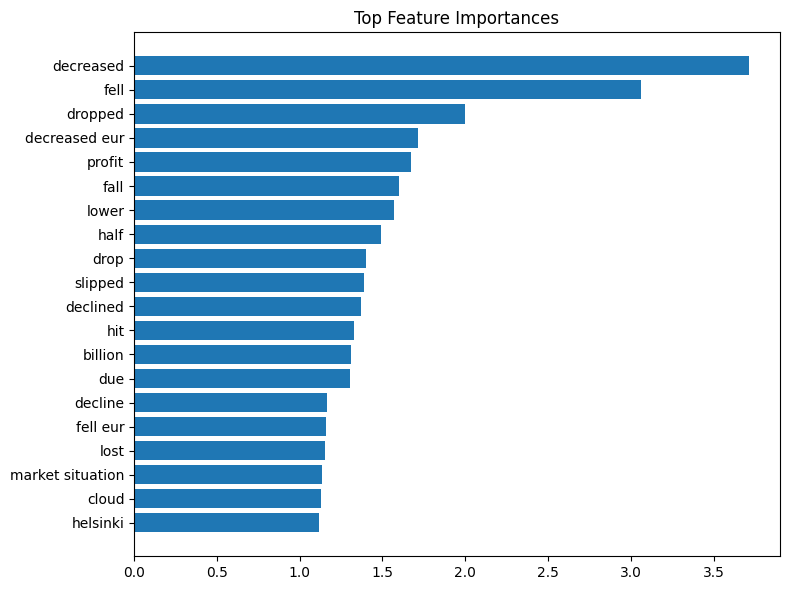

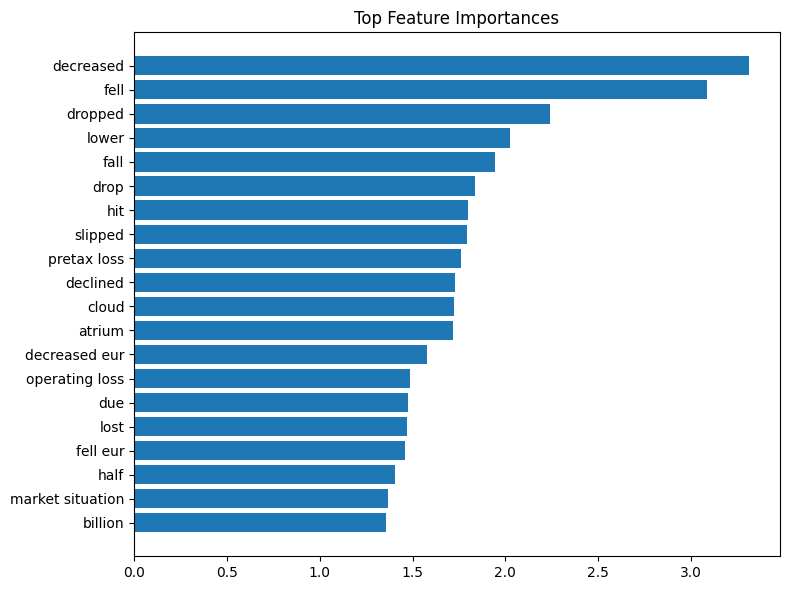

In [38]:
for name, model in models.items():
    print(f"Training {name}...")

    pipeline = train_model(model, X_train, y_train, max_features=tfidf_config["max_features"], ngram_range=tuple(tfidf_config["ngram_range"]))

    metrics = evaluate_model(pipeline, X_test, y_test)

    fig = get_feature_importance(pipeline, 20, (8,6), "Top Feature Importances")

    model_config = {
        "model": name,
        "params": model.get_params(),
        "tfidf": tfidf_config
    }

    save_experiment(
        model_name=name,
        pipeline=pipeline,
        metrics=metrics,
        config=model_config,
        feature_importance_fig=fig
    )

    print()